# 09 — Confounder Analysis: Do Demographics Predict Pathology?

**Goal**: Determine whether donor-level confounders (SEX, AGE, RACE, Hardy Scale,
Ischemic Time) alone can predict tissue pathology categories, and whether adding
them to expression features improves performance.

Three model comparisons:
1. **Model A** — RF with confounders only (5 features, no feature selection)
2. **Model B** — RF with expression + confounders (AUC-based FS on expression, confounders always included)
3. **Performance delta** — AUC(B) − AUC(A)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from gtex_biomarkers.config import Config
from gtex_biomarkers.data import (
    load_cache, variance_filter,
    build_confounder_matrix, CONFOUNDER_COLS,
)
from gtex_biomarkers.labels import discover_tissue_category_pairs
from gtex_biomarkers.models import make_rf_model
from gtex_biomarkers.utils import run_all_confounder_models_parallel
from gtex_biomarkers.evaluation import (
    plot_roc_grid, plot_boxplot_grid, plot_roc_overlay,
    plot_comparison_scatter, plot_comparison_barplot,
)

Config.ensure_dirs()

# Load cached data (run notebook 01 first)
X_wb, blood_subjid, _, df_meta_url, df_age = load_cache()

Loaded cache from /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/gtex_gene_expression/data/cache/processed_data.pkl
  X_wb: 803 samples × 59033 genes


## 9.1 — Build Confounder Matrix

Map donor-level demographics (SEX, AGE, RACE, DTHHRDY, TRISCHD) to each blood sample.
RACE codes 98/99 (unknown) are treated as NaN and median-imputed.

In [7]:
X_conf = build_confounder_matrix(df_age, blood_subjid)
print(f"Confounder matrix: {X_conf.shape[0]} samples × {X_conf.shape[1]} features")
print(f"Features: {list(X_conf.columns)}")
print()
display(X_conf.describe().round(2))
display(X_conf.head(10))

Confounder matrix: 803 samples × 5 features
Features: ['SEX', 'AGE', 'RACE', 'DTHHRDY', 'TRISCHD']



,SEX,AGE,RACE,DTHHRDY,TRISCHD
count,803.00,803.00,803.00,803.00,803.00
mean,1.33,52.81,2.85,1.12,491.91
std,0.47,13.03,0.40,1.40,410.54
min,1.00,20.00,1.00,0.00,0.00
25%,1.00,47.00,3.00,0.00,79.00
50%,1.00,55.00,3.00,0.00,447.00
75%,2.00,63.00,3.00,2.00,824.50
max,2.00,70.00,4.00,4.00,1641.00


,SEX,AGE,RACE,DTHHRDY,TRISCHD
GTEX-1117F-0005-SM-HL9SH,2,66,2.0,4.0,1200.0
GTEX-111CU-0005-SM-GJ3PH,1,57,3.0,0.0,43.0
GTEX-111FC-0006-SM-H65Z1,1,61,3.0,1.0,1028.0
GTEX-111YS-0006-SM-5NQBE,1,62,3.0,0.0,74.0
GTEX-1122O-0005-SM-5O99J,2,64,3.0,0.0,35.0
GTEX-1128S-0005-SM-5P9HI,2,66,3.0,2.0,816.0
GTEX-113IC-0006-SM-5NQ9C,1,66,2.0,0.0,94.0
GTEX-113JC-0006-SM-5O997,2,53,3.0,2.0,611.0
GTEX-117XS-0005-SM-5PNU6,1,64,3.0,2.0,848.0
GTEX-117YW-0005-SM-5NQ8Z,1,58,3.0,3.0,785.0


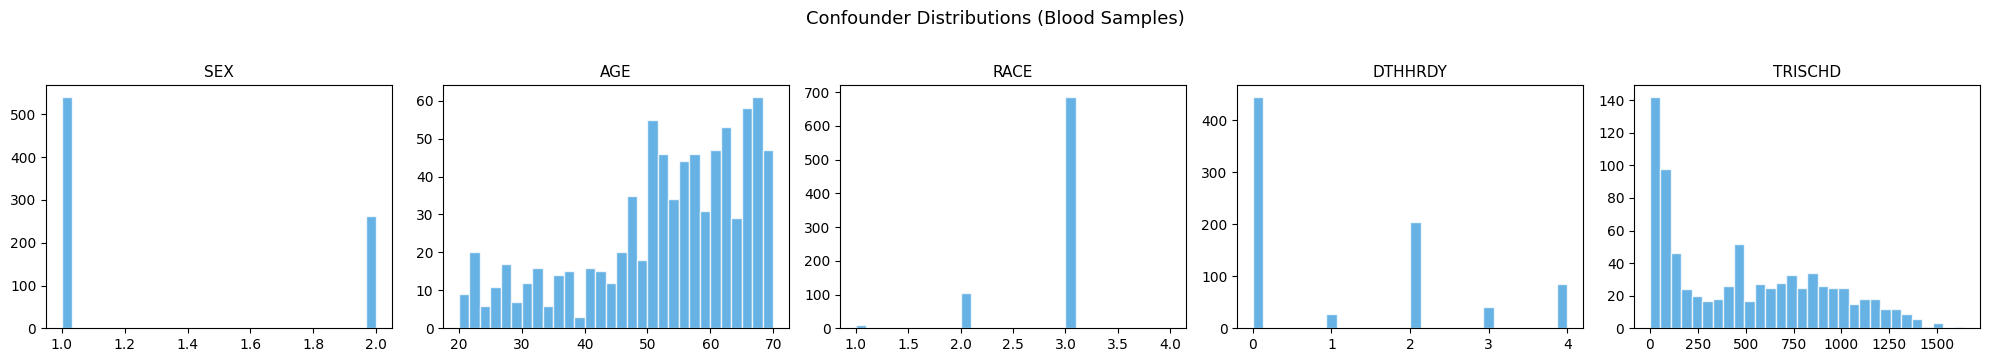

In [8]:
# Confounder distributions
fig, axes = plt.subplots(1, len(X_conf.columns), figsize=(4 * len(X_conf.columns), 3.5))
for ax, col in zip(axes, X_conf.columns):
    ax.hist(X_conf[col].dropna(), bins=30, color="#3498db", alpha=0.75, edgecolor="white")
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("")
fig.suptitle("Confounder Distributions (Blood Samples)", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / "confounder_distributions.pdf", bbox_inches="tight")
plt.show()

## 9.2 — Discover Tissue × Category Pairs

In [9]:
pairs_df = discover_tissue_category_pairs(df_meta_url)
print(f"Total tissue × category pairs (≥ {Config.ALL_TISSUE_THRESHOLD} samples): {len(pairs_df)}")
display(pairs_df)

Total tissue × category pairs (≥ 50 samples): 53


,tissue,category,n_samples
0,Adipose - Subcutaneous,fibrosis,137
1,Adipose - Visceral (Omentum),fibrosis,99
2,Artery - Aorta,atherosis,221
3,Artery - Aorta,atherosclerosis,101
4,Artery - Aorta,sclerotic,64
5,Artery - Aorta,calcification,53
6,Artery - Coronary,calcification,158
7,Artery - Coronary,atherosclerosis,153
8,Artery - Coronary,sclerotic,124
9,Artery - Coronary,atherosis,116


## 9.3 — Run Models (Parallelized by Tissue)

For each tissue × category pair, train two RF models in a single pass:
- **Model A**: Confounders only (SEX, AGE, RACE, DTHHRDY, TRISCHD) — no feature selection
- **Model B**: Variance-filtered expression (top 100 per fold) + all confounders

In [ ]:
# Variance-filtered expression (top 20K genes) — same as notebook 07
X_wb_var, _ = variance_filter(X_wb)
print(f"Variance-filtered expression: {X_wb_var.shape[0]} samples × {X_wb_var.shape[1]} genes")

conf_results, conf_summary, comb_results, comb_summary = \
    run_all_confounder_models_parallel(
        pairs_df, df_meta_url, blood_subjid,
        X_wb_var, X_conf, make_rf_model
    )

print(f"Completed {len(conf_results)} confounder-only models")
print(f"Completed {len(comb_results)} expression+confounder models")

Variance-filtered expression: 803 samples × 20000 genes


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


## 9.4 — Summary Tables

In [ ]:
# Save summaries
conf_summary.to_csv(Config.TABLES_DIR / "cv_results_confounder_only.csv", index=False)
comb_summary.to_csv(Config.TABLES_DIR / "cv_results_expr_plus_confounder.csv", index=False)

print("=== Model A: Confounder-Only RF ===")
display(conf_summary)
print()
print("=== Model B: Expression + Confounder RF ===")
display(comb_summary)

## 9.5 — Performance Delta: Expression+Confounder vs Confounder-Only

Compute AUC(Model B) − AUC(Model A) for each tissue × category pair.
Positive delta = expression features add value beyond confounders alone.

In [ ]:
# Build comparison table
comp = conf_summary[["tissue", "category", "mean_auc", "std_auc"]].merge(
    comb_summary[["tissue", "category", "mean_auc", "std_auc"]],
    on=["tissue", "category"],
    suffixes=("_conf", "_comb"),
)
comp["auc_delta"] = comp["mean_auc_comb"] - comp["mean_auc_conf"]
comp = comp.sort_values("auc_delta", ascending=False)
comp.to_csv(Config.TABLES_DIR / "cv_comparison_conf_vs_expr_conf.csv", index=False)

print(f"Models where expression adds value (delta > 0): {(comp['auc_delta'] > 0).sum()}/{len(comp)}")
print(f"Mean delta: {comp['auc_delta'].mean():.4f}")
print(f"Max delta:  {comp['auc_delta'].max():.4f}")
print()
display(comp)

## 9.6 — Figures

In [ ]:
# 9.6a — AUC delta bar chart (combined vs confounder-only)
s = comp.sort_values("auc_delta", ascending=True).copy()
s["label"] = s["tissue"] + " | " + s["category"]
colors = ["#2ecc71" if d > 0 else "#e74c3c" for d in s["auc_delta"]]

fig, ax = plt.subplots(figsize=(10, max(6, len(s) * 0.35)))
ax.barh(range(len(s)), s["auc_delta"], color=colors, alpha=0.85)
ax.set_yticks(range(len(s)))
ax.set_yticklabels(s["label"], fontsize=7)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("AUC delta (Expr+Conf − Conf-only)")
ax.set_title("Per-Model AUC Gain from Adding Expression to Confounders", fontsize=12)
ax.legend(
    handles=[Patch(color="#2ecc71", label="Expression helps"),
             Patch(color="#e74c3c", label="Expression hurts")],
    loc="lower right", fontsize=9,
)
fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / "confounder_delta_barplot.pdf", bbox_inches="tight")
plt.show()

In [ ]:
# 9.6b — Scatter: Confounder-only AUC (x) vs Combined AUC (y)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(comp["mean_auc_conf"], comp["mean_auc_comb"],
           s=40, alpha=0.7, edgecolors="black", lw=0.5)
ax.plot([0.3, 1], [0.3, 1], ls="--", color="grey", lw=1, label="Equal performance")
ax.axhline(0.5, ls=":", color="red", lw=0.6, alpha=0.4)
ax.axvline(0.5, ls=":", color="red", lw=0.6, alpha=0.4)

# Label top 5 biggest gains
top5 = comp.nlargest(5, "auc_delta")
for _, row in top5.iterrows():
    ax.annotate(f"{row['tissue'][:15]}|{row['category'][:10]}",
                (row["mean_auc_conf"], row["mean_auc_comb"]),
                fontsize=6, alpha=0.8, xytext=(5, 5), textcoords="offset points")

ax.set_xlabel("Confounder-Only AUC", fontsize=11)
ax.set_ylabel("Expression + Confounder AUC", fontsize=11)
ax.set_title("Confounder-Only vs Expression+Confounder", fontsize=12)
ax.set_xlim(0.3, 1.0); ax.set_ylim(0.3, 1.0)
ax.set_aspect("equal"); ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / "confounder_scatter.pdf", bbox_inches="tight")
plt.show()

In [ ]:
# 9.6c — Ranked bar chart: Confounder-only AUC for all models
s_conf = conf_summary.sort_values("mean_auc", ascending=True).copy()
s_conf["label"] = s_conf["tissue"] + " | " + s_conf["category"]
colors = ["#e67e22" if v >= 0.6 else "#95a5a6" for v in s_conf["mean_auc"]]

fig, ax = plt.subplots(figsize=(10, max(6, len(s_conf) * 0.35)))
ax.barh(range(len(s_conf)), s_conf["mean_auc"], color=colors,
        xerr=s_conf["std_auc"], capsize=2, ecolor="black", alpha=0.85)
ax.set_yticks(range(len(s_conf)))
ax.set_yticklabels(s_conf["label"], fontsize=7)
ax.axvline(0.5, ls=":", color="grey", lw=0.8, label="Random (0.5)")
ax.set_xlabel("Mean ROC-AUC (5-fold CV)")
ax.set_title("Confounder-Only RF — Ranked by AUC", fontsize=12)
ax.legend(loc="lower right", fontsize=8)
ax.set_xlim(0.3, 1.0)
fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / "confounder_only_ranked_barplot.pdf", bbox_inches="tight")
plt.show()

## 9.7 — Three-Way Comparison (Expression-Only vs Confounder-Only vs Combined)

Load expression-only RF results from notebook 07 output to see all three models side by side.

In [ ]:
# Load expression-only RF summary (from notebook 07)
expr_only_path = Config.TABLES_DIR / "cv_results_all_tissue_rf.csv"
if expr_only_path.exists():
    expr_summary = pd.read_csv(expr_only_path)

    # Three-way merge
    three_way = (
        conf_summary[["tissue", "category", "mean_auc"]]
        .rename(columns={"mean_auc": "auc_conf"})
        .merge(
            expr_summary[["tissue", "category", "mean_auc"]]
            .rename(columns={"mean_auc": "auc_expr"}),
            on=["tissue", "category"], how="outer",
        )
        .merge(
            comb_summary[["tissue", "category", "mean_auc"]]
            .rename(columns={"mean_auc": "auc_comb"}),
            on=["tissue", "category"], how="outer",
        )
    )
    three_way["delta_expr_vs_conf"] = three_way["auc_expr"] - three_way["auc_conf"]
    three_way["delta_comb_vs_expr"] = three_way["auc_comb"] - three_way["auc_expr"]
    three_way = three_way.sort_values("auc_comb", ascending=False)
    three_way.to_csv(Config.TABLES_DIR / "cv_three_way_comparison.csv", index=False)

    print("Three-way comparison (sorted by combined AUC):")
    display(three_way)
else:
    print("Expression-only RF results not found. Run notebook 07 first.")
    three_way = None

In [ ]:
# 9.7b — Grouped bar chart: three models side by side
if three_way is not None:
    tw = three_way.dropna(subset=["auc_conf", "auc_expr", "auc_comb"]).copy()
    tw["label"] = tw["tissue"] + " | " + tw["category"]
    tw = tw.sort_values("auc_comb", ascending=True)

    y_pos = np.arange(len(tw))
    bar_h = 0.25

    fig, ax = plt.subplots(figsize=(12, max(7, len(tw) * 0.55)))
    ax.barh(y_pos - bar_h, tw["auc_conf"], bar_h, label="Confounder-only",
            color="#e74c3c", alpha=0.8)
    ax.barh(y_pos, tw["auc_expr"], bar_h, label="Expression-only",
            color="#3498db", alpha=0.8)
    ax.barh(y_pos + bar_h, tw["auc_comb"], bar_h, label="Expr + Confounder",
            color="#2ecc71", alpha=0.8)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(tw["label"], fontsize=7)
    ax.axvline(0.5, ls=":", color="grey", lw=0.8)
    ax.set_xlabel("Mean ROC-AUC (5-fold CV)", fontsize=11)
    ax.set_title("Three-Way Model Comparison", fontsize=13)
    ax.legend(loc="lower right", fontsize=9)
    ax.set_xlim(0.3, 1.0)
    fig.tight_layout()
    fig.savefig(Config.FIGURES_DIR / "three_way_comparison_barplot.pdf", bbox_inches="tight")
    plt.show()

## 9.8 — ROC Curves for Confounder-Only Models

In [ ]:
plot_roc_grid(conf_results,
             suptitle="Confounder-Only RF — ROC (5-fold CV)",
             save_path=Config.FIGURES_DIR / "roc_confounder_only.pdf")

plot_boxplot_grid(conf_results,
                  suptitle="Confounder-Only RF — Box Plots",
                  save_path=Config.FIGURES_DIR / "boxplot_confounder_only.pdf")

## 9.9 — ROC Curves for Expression + Confounder Models

In [ ]:
plot_roc_grid(comb_results,
             suptitle="Expression + Confounder RF — ROC (5-fold CV)",
             save_path=Config.FIGURES_DIR / "roc_expr_plus_confounder.pdf")

plot_boxplot_grid(comb_results,
                  suptitle="Expression + Confounder RF — Box Plots",
                  save_path=Config.FIGURES_DIR / "boxplot_expr_plus_confounder.pdf")